## Классификация: превышает ли значение SI значение 8

In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, recall_score, accuracy_score, precision_score, f1_score, roc_auc_score, roc_curve
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import average_precision_score, precision_recall_curve

In [88]:
PROJECT_ROOT = Path.cwd().parents[1]
CSV_PATH = PROJECT_ROOT / Path("./data/si_8_threshold.csv").resolve()
print(CSV_PATH)

E:\Study\projects\coursework_classic_ml\data\si_8_threshold.csv


In [89]:
df = pd.read_csv(CSV_PATH)
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,NumRadicalElectrons,MinPartialCharge,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,threshold
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,0,-0.293526,...,0,0,0,0,0,0,0,3,0,1
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,0,-0.313407,...,0,0,0,0,0,0,0,3,0,0
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,0,-0.325573,...,0,0,0,0,0,0,0,3,0,0
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,0,-0.293526,...,0,0,0,0,0,0,0,4,0,1
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,0,-0.257239,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='threshold', ylabel='Count'>

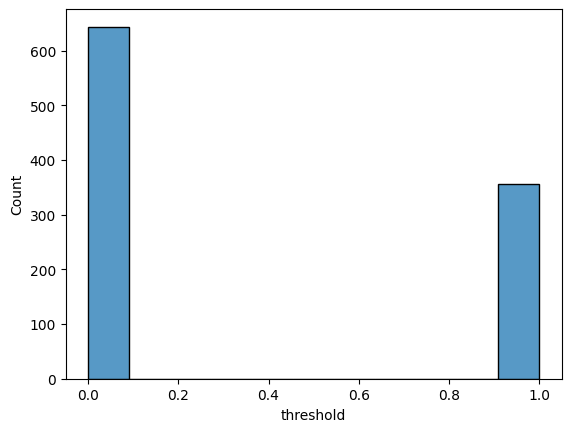

In [90]:
sns.histplot(df['threshold'])

из графика видно, что распределение классов по признаку median_threshold имеет дисбаланс но не очень сильный, для сравнения в некоторые модели добавлю class_weight, классс 1 - значит превышает значение IC50 медианное значение выборки, класс 0 - не превышает

In [91]:
X_si = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI', 'threshold'])
y_si = df['threshold']
X_train, X_test, y_train, y_test = train_test_split(X_si, y_si, test_size=0.1, random_state=42, stratify=y_si)
pipeline = Pipeline([('scaler', StandardScaler()),
                      ('model', LogisticRegression(C=1))])
pipeline.fit(X_train, y_train)
pred_train = pipeline.predict(X_train)
pred_test = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

In [92]:
print(f"confusion matrix train:")
print(f"{confusion_matrix(y_train, pred_train)}")

confusion matrix train:
[[512  67]
 [124 197]]


In [93]:
print(f"confusion matrix test:")
print(f"{confusion_matrix(y_test, pred_test)}")


confusion matrix test:
[[51 14]
 [20 16]]


In [94]:
print("LogisticRegression метрики train:")
print(classification_report(y_train, pred_train))
print("LogisticRegression метрики test:")
print(classification_report(y_test, pred_test))

LogisticRegression метрики train:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       579
           1       0.75      0.61      0.67       321

    accuracy                           0.79       900
   macro avg       0.78      0.75      0.76       900
weighted avg       0.78      0.79      0.78       900

LogisticRegression метрики test:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75        65
           1       0.53      0.44      0.48        36

    accuracy                           0.66       101
   macro avg       0.63      0.61      0.62       101
weighted avg       0.65      0.66      0.66       101



для LogisticRegression есть переобучение, модель значительно лучше находит класс который не превышает медианное значение recall = 0.78,  чем который не превышает, так как recall выше, хуже распознает класс который больше чем медианное значение recall = 0.44, часть объектов ошибочно относиться к классу который превышает медианное значение. Ошибается модель больше для класса который не превышает медианное значение precision = 0.72, против класса который больше чем медианное значение precision = 0.53. Производительность модели низкая

In [95]:
pipeline_cw = Pipeline([('scaler', StandardScaler()),
                      ('model', LogisticRegression(C=1, class_weight='balanced', max_iter=2000))])    
pipeline_cw.fit(X_train, y_train)
pred_train_cw = pipeline_cw.predict(X_train)
pred_test_cw = pipeline_cw.predict(X_test)
y_proba_cw = pipeline_cw.predict_proba(X_test)[:, 1]

In [96]:
print(f"confusion matrix train с class_weight:")
print(f"{confusion_matrix(y_train, pred_train_cw)}")

confusion matrix train с class_weight:
[[441 138]
 [ 88 233]]


In [97]:
print(f"confusion matrix test с class_weight:")
print(f"{confusion_matrix(y_test, pred_test_cw)}")

confusion matrix test с class_weight:
[[38 27]
 [15 21]]


In [98]:
print("LogisticRegression метрики train с class_weight:")
print(classification_report(y_train, pred_train_cw))
print("LogisticRegression метрики test с class_weight:")
print(classification_report(y_test, pred_test_cw))

LogisticRegression метрики train с class_weight:
              precision    recall  f1-score   support

           0       0.83      0.76      0.80       579
           1       0.63      0.73      0.67       321

    accuracy                           0.75       900
   macro avg       0.73      0.74      0.73       900
weighted avg       0.76      0.75      0.75       900

LogisticRegression метрики test с class_weight:
              precision    recall  f1-score   support

           0       0.72      0.58      0.64        65
           1       0.44      0.58      0.50        36

    accuracy                           0.58       101
   macro avg       0.58      0.58      0.57       101
weighted avg       0.62      0.58      0.59       101



для LogisticRegression с class_weigh на тестовой выборке стало хуже, по сравнению со стандартной моднлью,  есть большое переобучение, модель одинаково предсказыает оба класса precision и recall равным 0.58 . Ошибается модель больше для класса который превышает медианное значение precision = 0.72, против класса который меньше чем медианное значение precision = 0.44. Производительность модели низкя

In [99]:
xgb = XGBClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 7, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
    'alpha': [0, 0.1, 1],
    'lambda': [1, 5, 10]
}
grid_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=1,
    verbose=1
)
grid_search_xgb.fit(X_train, y_train)
print(f"лучшие параметры: {grid_search_xgb.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
лучшие параметры: {'subsample': 1, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'lambda': 10, 'colsample_bytree': 0.7, 'alpha': 1}


In [100]:
pred_train_xgb = grid_search_xgb.best_estimator_.predict(X_train)
pred_test_xgb = grid_search_xgb.best_estimator_.predict(X_test)
y_proba_xgb = grid_search_xgb.best_estimator_.predict_proba(X_test)[:, 1]
print("XGBClassifier метрики train:")
print(f"{classification_report(y_train, pred_train_xgb)}")
print("XGBClassifier метрики test:")
print(f"{classification_report(y_test, pred_test_xgb)}")

XGBClassifier метрики train:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       579
           1       0.88      0.76      0.82       321

    accuracy                           0.88       900
   macro avg       0.88      0.85      0.86       900
weighted avg       0.88      0.88      0.88       900

XGBClassifier метрики test:
              precision    recall  f1-score   support

           0       0.75      0.85      0.80        65
           1       0.64      0.50      0.56        36

    accuracy                           0.72       101
   macro avg       0.70      0.67      0.68       101
weighted avg       0.71      0.72      0.71       101



для XGBClassifier есть переобучение, модель значительно лучше находит класс который не превышает медианное значение recall = 0.85,  чем класс который превышает, так как recall выше, хуже распознает класс который больше чем медианное значение recall = 0.50, часть объектов ошибочно относиться к классу который превышает медианное значение. Ошибается модель больше для класса который превышает медианное значение precision = 0.64, против класса который меньше чем медианное значение precision = 0.75. Производительность модели на тесте нормальная

In [101]:
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

rfc = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}
random_search_rf_cw = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_grid_rf,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=1,
    verbose=1,
    random_state=42
)
random_search_rf_cw.fit(X_train, y_train, sample_weight=sample_weights)
print(f"лучшие параметры: {random_search_rf_cw.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
лучшие параметры: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 7}


In [102]:
pred_train_rf_cw = random_search_rf_cw.best_estimator_.predict(X_train)
pred_test_rf_cw = random_search_rf_cw.best_estimator_.predict(X_test)
y_proba_rf_cw = random_search_rf_cw.best_estimator_.predict_proba(X_test)[:, 1]
print("RandomForestClassifier метрики train c class_weight:")
print(f"{classification_report(y_train, pred_train_rf_cw)}")
print("RandomForestClassifier метрики test c class_weight:")
print(f"{classification_report(y_test, pred_test_rf_cw)}")

RandomForestClassifier метрики train c class_weight:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       579
           1       0.77      0.78      0.77       321

    accuracy                           0.84       900
   macro avg       0.82      0.82      0.82       900
weighted avg       0.84      0.84      0.84       900

RandomForestClassifier метрики test c class_weight:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        65
           1       0.61      0.64      0.62        36

    accuracy                           0.72       101
   macro avg       0.70      0.70      0.70       101
weighted avg       0.73      0.72      0.72       101



для RandomForestClassifier c class_weight есть переобучение, модель лучше находит класс который не превышает медианное значение recall = 0.77,  чем класс который превышает, так как recall выше, хуже распознает класс который больше чем медианное значение recall = 0.64, часть объектов ошибочно относиться к классу который превышает медианное значение. Ошибается модель больше для класса который превышает медианное значение precision = 0.61, против класса который больше чем медианное значение precision = 0.79. Производительность модели на тесте нормальная

In [103]:
rfc = RandomForestClassifier(random_state=42)
random_search_rf = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_grid_rf,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=1,
    verbose=1,
    random_state=42
)
random_search_rf.fit(X_train, y_train, sample_weight=sample_weights)
print(f"лучшие параметры: {random_search_rf.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
лучшие параметры: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 7}


In [104]:
pred_train_rf = random_search_rf.best_estimator_.predict(X_train)
pred_test_rf = random_search_rf.best_estimator_.predict(X_test)
y_proba_rf = random_search_rf.best_estimator_.predict_proba(X_test)[:, 1]
print("RandomForestClassifier метрики train:")
print(f"{classification_report(y_train, pred_train_rf)}")
print("RandomForestClassifier метрики test:")
print(f"{classification_report(y_test, pred_test_rf)}")

RandomForestClassifier метрики train:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       579
           1       0.77      0.78      0.77       321

    accuracy                           0.84       900
   macro avg       0.82      0.82      0.82       900
weighted avg       0.84      0.84      0.84       900

RandomForestClassifier метрики test:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        65
           1       0.61      0.64      0.62        36

    accuracy                           0.72       101
   macro avg       0.70      0.70      0.70       101
weighted avg       0.73      0.72      0.72       101



для RandomForestClassifier class_weight не дал положительного эфекта, у стандартной модели есть переобучение, модель лучше находит класс который не превышает медианное значение recall = 0.77,  чем класс который превышает, так как recall выше, хуже распознает класс который больше чем медианное значение recall = 0.64, часть объектов ошибочно относиться к классу который превышает медианное значение. Ошибается модель больше для класса который превышает медианное значение precision = 0.61, против класса который больше чем медианное значение precision = 0.79. Производительность модели на тесте нормальная

In [125]:
accuracy_log_train = accuracy_score(y_train, pred_train)
recall_logb_train = recall_score(y_train, pred_train)
precision_log_train = precision_score(y_train, pred_train)
f1_log_train = f1_score(y_train, pred_train)
accuracy_log_test = accuracy_score(y_test, pred_test)
recall_logb_test = recall_score(y_test, pred_test)
precision_log_test = precision_score(y_test, pred_test)
f1_log_test = f1_score(y_test, pred_test)
roc_auc_test = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
prauctest = average_precision_score(y_test, y_proba)
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)

accuracy_log_train_cw = accuracy_score(y_train, pred_train_cw)
recall_logb_train_cw = recall_score(y_train, pred_train_cw)
precision_log_train_cw = precision_score(y_train, pred_train_cw)
f1_log_train_cw = f1_score(y_train, pred_train_cw)
accuracy_log_test_cw = accuracy_score(y_test, pred_test_cw)
recall_logb_test_cw = recall_score(y_test, pred_test_cw)
precision_log_test_cw = precision_score(y_test, pred_test_cw)
f1_log_test_cw = f1_score(y_test, pred_test_cw)
roc_auc_test_cw = roc_auc_score(y_test, y_proba_cw)
fpr_cw, tpr_cw, thresholds_cw = roc_curve(y_test, y_proba_cw)
prauctest_cw = average_precision_score(y_test, y_proba_cw)
precision_cw, recall_cw, thresholds_pr_cw = precision_recall_curve(y_test, y_proba_cw)

accuracy_xgb_train = accuracy_score(y_train, pred_train_xgb)
recall_xgb_train = recall_score(y_train, pred_train_xgb)
precision_xgb_train = precision_score(y_train, pred_train_xgb)
f1_xgb_train = f1_score(y_train, pred_train_xgb)
accuracy_xgb_test = accuracy_score(y_test, pred_test_xgb)
recall_xgb_test = recall_score(y_test, pred_test_xgb)
precision_xgb_test = precision_score(y_test, pred_test_xgb)
f1_xgb_test = f1_score(y_test, pred_test_xgb)
roc_auc_test_xgb = roc_auc_score(y_test, y_proba_xgb)
fpr_xgb, tpr_xgb, thresholds = roc_curve(y_test, y_proba_xgb)
prauctestxgb = average_precision_score(y_test, y_proba_xgb)
precisionxgb, recallxgb, thresholds_prxgb = precision_recall_curve(y_test, y_proba_xgb)

accuracy_rf_train = accuracy_score(y_train, pred_train_rf)
recall_rf_train = recall_score(y_train, pred_train_rf)
precision_rf_train = precision_score(y_train, pred_train_rf)
f1_rf_train = f1_score(y_train, pred_train_rf)
accuracy_rf_test = accuracy_score(y_test, pred_test_rf)
recall_rf_test = recall_score(y_test, pred_test_rf)
precision_rf_test = precision_score(y_test, pred_test_rf)
f1_rf_test = f1_score(y_test, pred_test_rf)
roc_auc_test_rf = roc_auc_score(y_test, y_proba_rf)
fpr_rf, tpr_rf, thresholds = roc_curve(y_test, y_proba_rf)
prauctestrf = average_precision_score(y_test, y_proba_rf)
precisionrf, recallrf, thresholds_prrf = precision_recall_curve(y_test, y_proba_rf)

accuracy_rf_train_cw = accuracy_score(y_train, pred_train_rf_cw)
recall_rf_train_cw = recall_score(y_train, pred_train_rf_cw)
precision_rf_train_cw = precision_score(y_train, pred_train_rf_cw)
f1_rf_train_cw = f1_score(y_train, pred_train_rf_cw)
accuracy_rf_test_cw = accuracy_score(y_test, pred_test_rf_cw)
recall_rf_test_cw = recall_score(y_test, pred_test_rf_cw)
precision_rf_test_cw = precision_score(y_test, pred_test_rf_cw)
f1_rf_test_cw = f1_score(y_test, pred_test_rf_cw)
roc_auc_test_rf_cw = roc_auc_score(y_test, y_proba_rf_cw)
fpr_rf_cw, tpr_rf_cw, thresholds_cw = roc_curve(y_test, y_proba_rf_cw)
prauctestrf_cw = average_precision_score(y_test, y_proba_rf_cw)
precisionrf_cw, recallrf_cw, thresholds_prrf_cw = precision_recall_curve(y_test, y_proba_rf_cw)



In [129]:
f1_retrain = [f1_log_train - f1_log_test, f1_xgb_train - f1_xgb_test, f1_rf_train - f1_rf_test, f1_log_train_cw - f1_log_test_cw,  f1_rf_train_cw - f1_rf_test_cw]
accuracy_retrain = [accuracy_log_train - accuracy_log_test, accuracy_xgb_train - accuracy_xgb_test, accuracy_rf_train - accuracy_rf_test, accuracy_log_train_cw - accuracy_log_test_cw, accuracy_rf_train_cw - accuracy_rf_test_cw]

In [118]:
df_metrics_train = pd.DataFrame({
    'Model': ['LogRegr', 'XGBoost', 'RandomForest', 'LogRegr_class_w', 'RandomForest_class_w'],
    'Accuracy': [accuracy_log_train, accuracy_xgb_train, accuracy_rf_train, accuracy_log_train_cw, accuracy_rf_train_cw],
    'Precision': [precision_log_train, precision_xgb_train, precision_rf_train, precision_log_train_cw, precision_rf_train_cw],
    'Recall': [recall_logb_train, recall_xgb_train, recall_rf_train,  recall_logb_train_cw, recall_rf_train_cw],
    'f1': [f1_log_train, f1_xgb_train, f1_rf_train, f1_log_train_cw, f1_rf_train_cw]
})

df_metrics_test = pd.DataFrame({
    'Model': ['LogRegr', 'XGBoost', 'RandomForest', 'LogRegr_class_w', 'RandomForest_class_w'],
    'Accuracy': [accuracy_log_test, accuracy_xgb_test, accuracy_rf_test, accuracy_log_test_cw, accuracy_rf_test_cw],
    'Precision': [precision_log_test, precision_xgb_test, precision_rf_test, precision_log_test_cw, precision_rf_test_cw],
    'Recall': [recall_logb_test, recall_xgb_test, recall_rf_test, recall_logb_test_cw, recall_rf_test_cw],
    'f1': [f1_log_test, f1_xgb_test, f1_rf_test, f1_log_test_cw, f1_rf_test_cw]
})

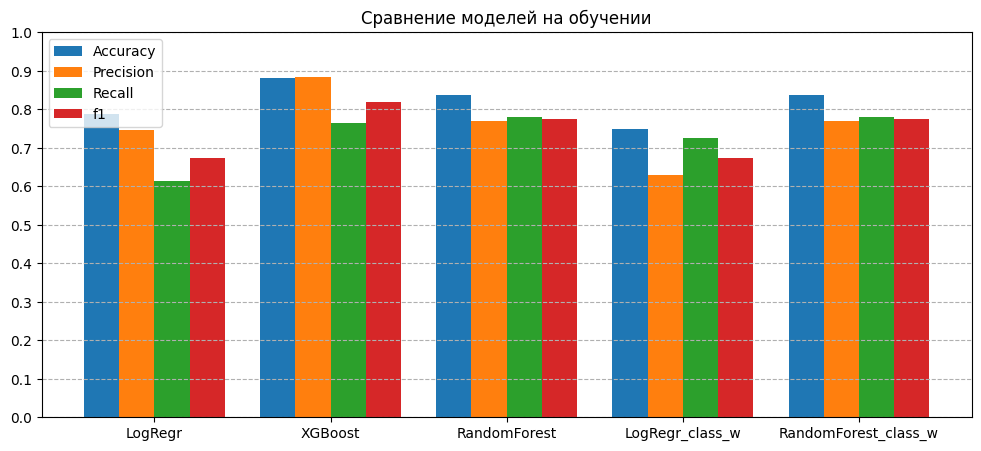

In [116]:
plt.figure(figsize=(12, 5))
width = 0.2
x = np.arange(len(df_metrics_train['Model']))
plt.bar(x - 1.5 * width, df_metrics_train['Accuracy'], width, label='Accuracy')
plt.bar(x - 0.5 * width, df_metrics_train['Precision'], width, label='Precision')
plt.bar(x + 0.5 * width, df_metrics_train['Recall'], width, label='Recall')
plt.bar(x + 1.5 * width, df_metrics_train['f1'], width, label='f1')
plt.xticks(x, df_metrics_train['Model'])
plt.legend()
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='y',linestyle= '--')
plt.title('Сравнение моделей на обучении')
plt.show()

лучше всех на обучении производительность у модели XGBoost, class_weight для логистической регрессии и для RandomForest, не дало положительного эффекта

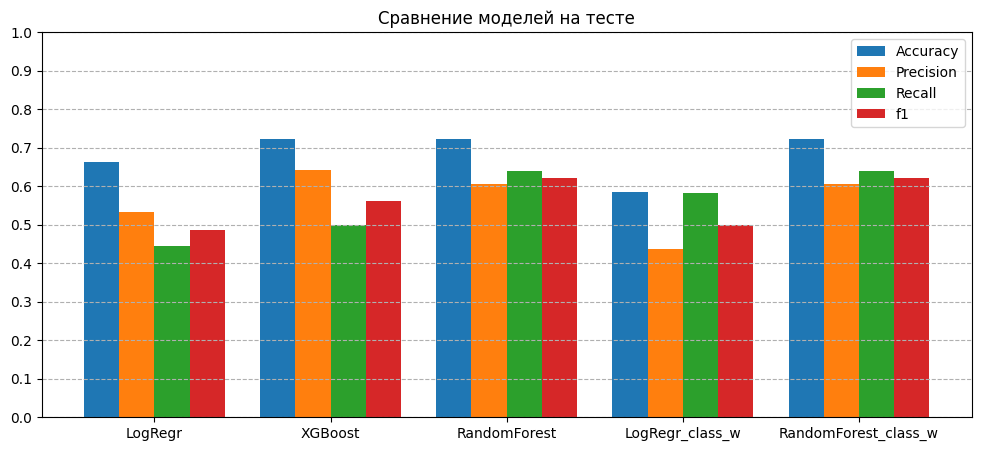

In [134]:
plt.figure(figsize=(12, 5))
width = 0.2
x = np.arange(len(df_metrics_test['Model']))
plt.bar(x - 1.5 * width, df_metrics_test['Accuracy'], width, label='Accuracy')
plt.bar(x - 0.5 * width, df_metrics_test['Precision'], width, label='Precision')
plt.bar(x + 0.5 * width, df_metrics_test['Recall'], width, label='Recall')
plt.bar(x + 1.5 * width, df_metrics_test['f1'], width, label='f1')
plt.xticks(x, df_metrics_test['Model'])
plt.legend()
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='y',linestyle= '--')
plt.title('Сравнение моделей на тесте')
plt.show()

на тестовой выборки лучше показали ансамбли, class_weight для логистической регрессии и для RandomForest, не дало положительного эффекта

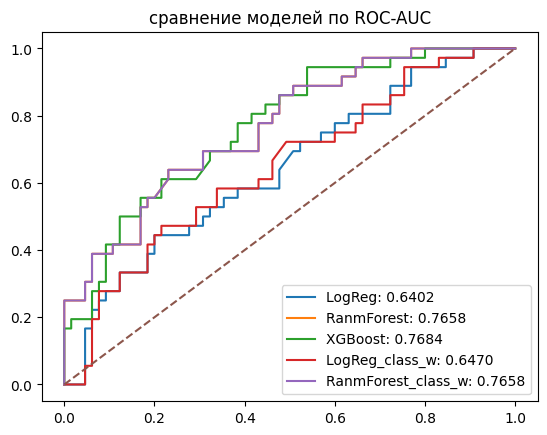

In [117]:
plt.plot(fpr, tpr, label=f'LogReg: {roc_auc_test:.4f}',)
plt.plot(fpr_rf, tpr_rf, label=f'RanmForest: {roc_auc_test_rf:.4f}')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost: {roc_auc_test_xgb:.4f}')
plt.plot(fpr_cw, tpr_cw, label=f'LogReg_class_w: {roc_auc_test_cw:.4f}',)
plt.plot(fpr_rf_cw, tpr_rf_cw, label=f'RanmForest_class_w: {roc_auc_test_rf_cw:.4f}')
plt.plot([0, 1], [0, 1], linestyle= '--')
plt.title('сравнение моделей по ROC-AUC')
plt.legend()
plt.show()

по ROC-AUC лучшей моделью выглядит XGBoost, а оба варианта RandomForest идут почти сразу за ним, Logistic Regression заметно слабее, class_weight для логистической регрессии и для RandomForest, не дало положительного эффекта

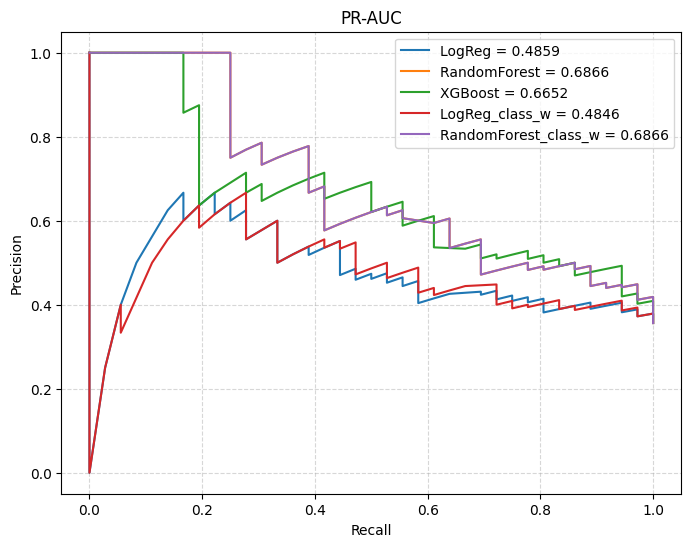

In [128]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'LogReg = {prauctest:.4f}')
plt.plot(recallrf, precisionrf, label=f'RandomForest = {prauctestrf:.4f}')
plt.plot(recallxgb, precisionxgb, label=f'XGBoost = {prauctestxgb:.4f}')
plt.plot(recall_cw, precision_cw, label=f'LogReg_class_w = {prauctest_cw:.4f}')
plt.plot(recallrf_cw, precisionrf_cw, label=f'RandomForest_class_w = {prauctestrf_cw:.4f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-AUC')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.show()

так как есть дисбаланс класса добавил PR-AUC, лучшей моделью выглядит RandomForest, а XGBoots идет за ним, Logistic Regression заметно слабее, class_weight для логистической регрессии и для RandomForest, не дало положительного эффекта

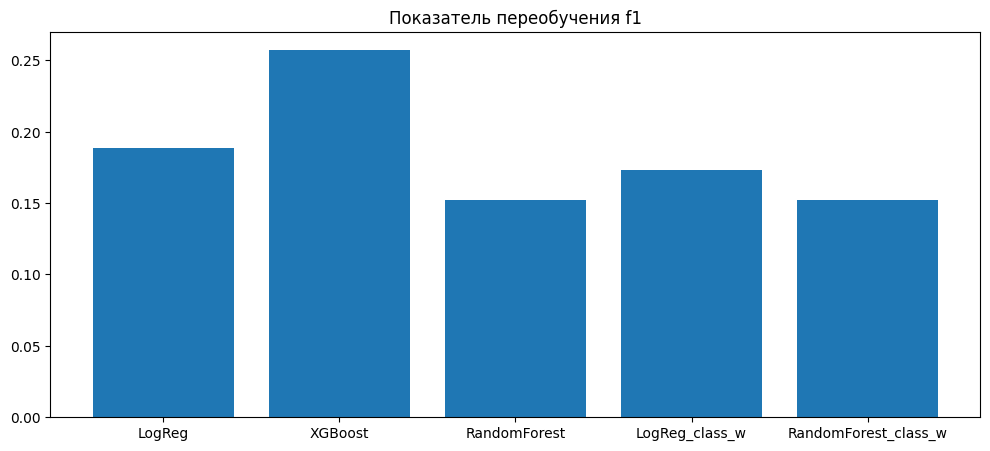

In [135]:
plt.figure(figsize=(12, 5))
plt.bar(['LogReg', 'XGBoost', 'RandomForest', 'LogReg_class_w', 'RandomForest_class_w'], f1_retrain)
plt.title('Показатель переобучения f1')
plt.show()

для f1 у всех моделей есть переобучение, больше всего XGBoost, меньше всего у RandomForest, class_weight для логистической регрессии помог снизить переобучение

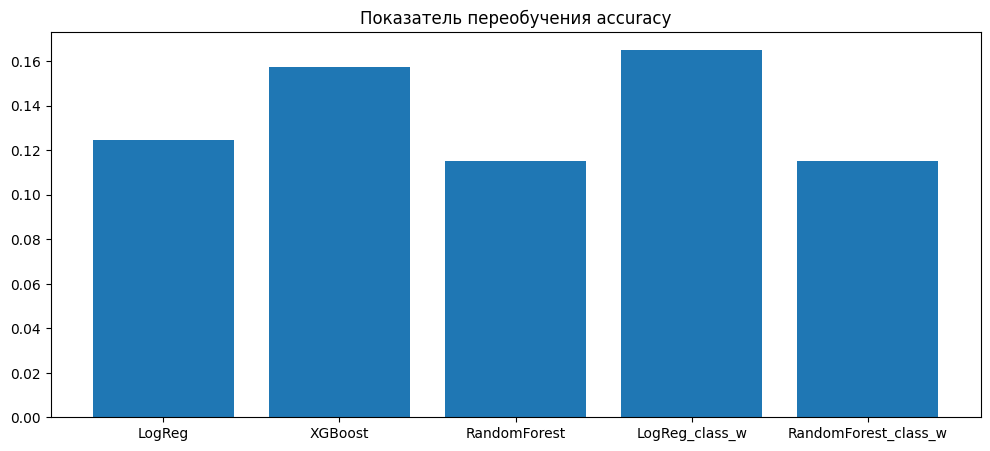

In [136]:
plt.figure(figsize=(12, 5))
plt.bar(['LogReg', 'XGBoost', 'RandomForest', 'LogReg_class_w', 'RandomForest_class_w'], accuracy_retrain)
plt.title('Показатель переобучения accuracy')
plt.show()

для accuracy у всех моделей есть переобучение, больше всего XGBoost и логистической регрессии с class_weight , class_weight увеличил переобучение для логистической регрессии, а для RandomForest нет

Вывод: так как есть дисбаланс классов, для сравнения был добавлен class_weight для базовой модели логистической регрессии и RandomForest, class_weight не дало положительного эффекта, для логистической регрессии сделал даже хуже, больше переобучение и хуже метрики. Я думаю что class_weight не дал эффекта, потому что нет сильного дисбаланса класса. Лучшая модель это RandomForest, самое маленькое переобучение и лучше метрики